In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("housing_data.xlsx", sheet_name="Data Collection")

df.head()

,Property_ID,Suburb,Address,Sale_Price_AUD,Sale_Date,Property_Type,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Building_or_Strata_Area_m2,Source_URL,Notes
0,1,Abbotsbury,76 Stockdale Crescent,1690000,2026-08-24,House,4,3,3.0,685.0,NaN,https://www.realestate.com.au/sold/property-ho...,NaN
1,2,Abbotsbury,28 Driscoll Street,1795000,2026-08-22,House,4,2,2.0,745.6,NaN,https://www.realestate.com.au/sold/property-ho...,NaN
2,3,Abbotsbury,13 Ogden Close,1601000,2026-08-22,House,4,2,3.0,608.0,NaN,https://www.realestate.com.au/sold/property-ho...,NaN
3,4,Abbotsbury,5 Kiernan Crescent,1800000,2026-08-09,House,4,2,2.0,531.0,NaN,https://www.realestate.com.au/sold/property-ho...,NaN
4,5,Abbotsbury,9 Comin Place,1753000,2026-06-17,House,4,3,2.0,749.0,NaN,https://www.realestate.com.au/sold/property-ho...,NaN


In [6]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (105, 13)

Column names:
['Property_ID', 'Suburb', 'Address', 'Sale_Price_AUD', 'Sale_Date', 'Property_Type', 'Bedrooms', 'Bathrooms', 'Car_Spaces', 'Land_Size_m2', 'Building_or_Strata_Area_m2', 'Source_URL', 'Notes']

Data types:
Property_ID                            int64
Suburb                                object
Address                               object
Sale_Price_AUD                         int64
Sale_Date                     datetime64[ns]
Property_Type                         object
Bedrooms                               int64
Bathrooms                              int64
Car_Spaces                           float64
Land_Size_m2                         float64
Building_or_Strata_Area_m2           float64
Source_URL                            object
Notes                                 object
dtype: object

Missing values:
Property_ID                     0
Suburb                          0
Address                         0
Sale_Price_AUD                  0
Sa

In [7]:
df = df.drop(columns=["Building_or_Strata_Area_m2"])

print("Updated shape:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

Updated shape: (105, 12)

Remaining columns:
['Property_ID', 'Suburb', 'Address', 'Sale_Price_AUD', 'Sale_Date', 'Property_Type', 'Bedrooms', 'Bathrooms', 'Car_Spaces', 'Land_Size_m2', 'Source_URL', 'Notes']


In [8]:
duplicates = df.duplicated(subset=["Suburb", "Address"]).sum()

print("Duplicate properties:", duplicates)

Duplicate properties: 0


In [9]:
print(df["Suburb"].value_counts())

Suburb
Abbotsbury        35
Acacia Gardens    35
Airds             35
Name: count, dtype: int64


In [10]:
property_types = pd.crosstab(df["Suburb"], df["Property_Type"])

print(property_types)

Property_Type   Duplex  House  Townhouse
Suburb                                  
Abbotsbury           0     35          0
Acacia Gardens       5     22          8
Airds                0     35          0


In [11]:
numeric_summary = df[
    ["Sale_Price_AUD", "Bedrooms", "Bathrooms", "Car_Spaces", "Land_Size_m2"]
].describe()

print(numeric_summary)

       Sale_Price_AUD    Bedrooms  Bathrooms  Car_Spaces  Land_Size_m2
count    1.050000e+02  105.000000  105.00000  102.000000     84.000000
mean     1.386933e+06    3.980952    2.12381    1.911765    539.586905
std      4.694983e+05    0.919667    0.79294    1.328313    147.634208
min      6.850000e+05    3.000000    1.00000    1.000000    192.000000
25%      9.900000e+05    3.000000    2.00000    1.000000    450.900000
50%      1.275000e+06    4.000000    2.00000    2.000000    548.500000
75%      1.691500e+06    4.000000    3.00000    2.000000    619.200000
max      2.630000e+06    7.000000    4.00000   13.000000   1049.000000


In [12]:
suburb_price_summary = df.groupby("Suburb")["Sale_Price_AUD"].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

print(suburb_price_summary)

                count          mean     median      min      max  \
Suburb                                                             
Abbotsbury         35  1.938014e+06  1868000.0  1556000  2630000   
Acacia Gardens     35  1.247000e+06  1255000.0   890000  1670000   
Airds              35  9.757857e+05   907000.0   685000  1310000   

                          std  
Suburb                         
Abbotsbury      291823.639472  
Acacia Gardens  234213.357985  
Airds           165654.907320  


<Figure size 800x500 with 0 Axes>

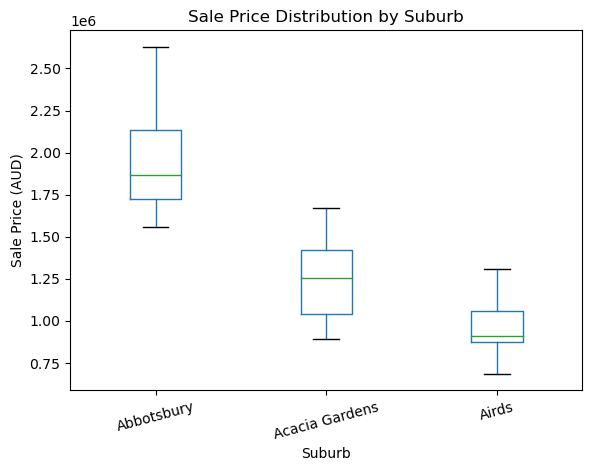

In [13]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Sale_Price_AUD",
    by="Suburb",
    grid=False
)

plt.title("Sale Price Distribution by Suburb")
plt.suptitle("")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")
plt.xticks(rotation=15)

plt.show()

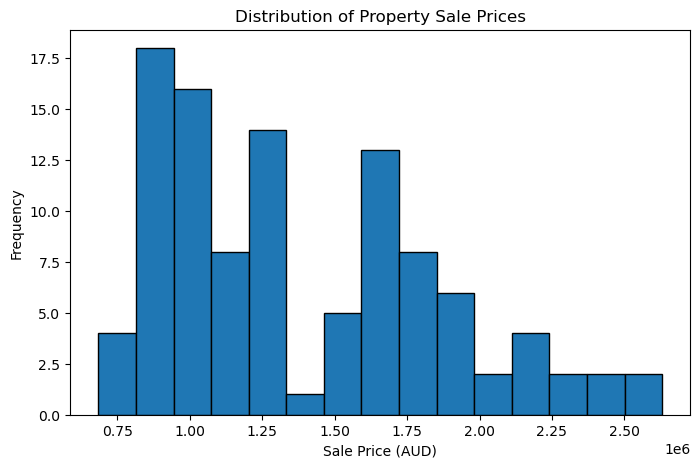

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(df["Sale_Price_AUD"], bins=15, edgecolor="black")

plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sale Price (AUD)")
plt.ylabel("Frequency")

plt.show()

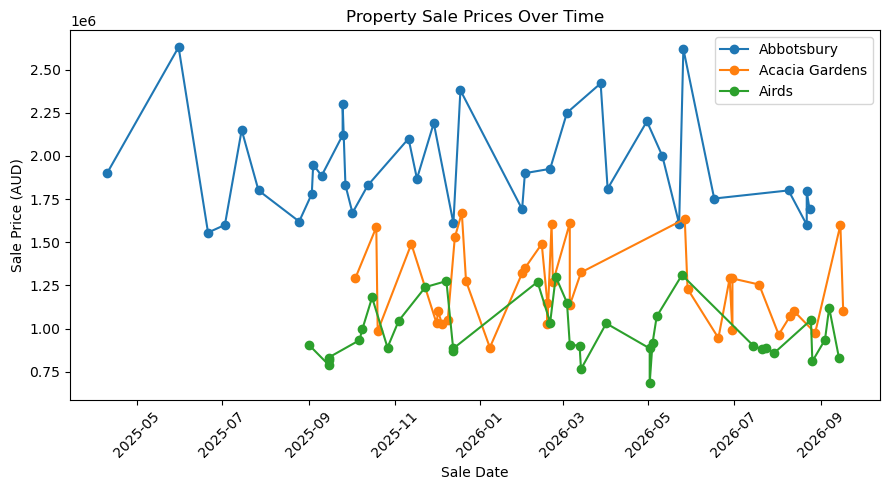

In [15]:
plt.figure(figsize=(9, 5))

for suburb in df["Suburb"].unique():
    subset = df[df["Suburb"] == suburb].sort_values("Sale_Date")
    
    plt.plot(
        subset["Sale_Date"],
        subset["Sale_Price_AUD"],
        marker="o",
        label=suburb
    )

plt.title("Property Sale Prices Over Time")
plt.xlabel("Sale Date")
plt.ylabel("Sale Price (AUD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
df["Year_Month"] = df["Sale_Date"].dt.to_period("M").astype(str)

monthly_prices = (
    df.groupby(["Year_Month", "Suburb"])["Sale_Price_AUD"]
      .median()
      .reset_index()
)

monthly_prices.head()

,Year_Month,Suburb,Sale_Price_AUD
0,2025-04,Abbotsbury,1900000.0
1,2025-05,Abbotsbury,2630000.0
2,2025-06,Abbotsbury,1556000.0
3,2025-07,Abbotsbury,1800000.0
4,2025-08,Abbotsbury,1620000.0


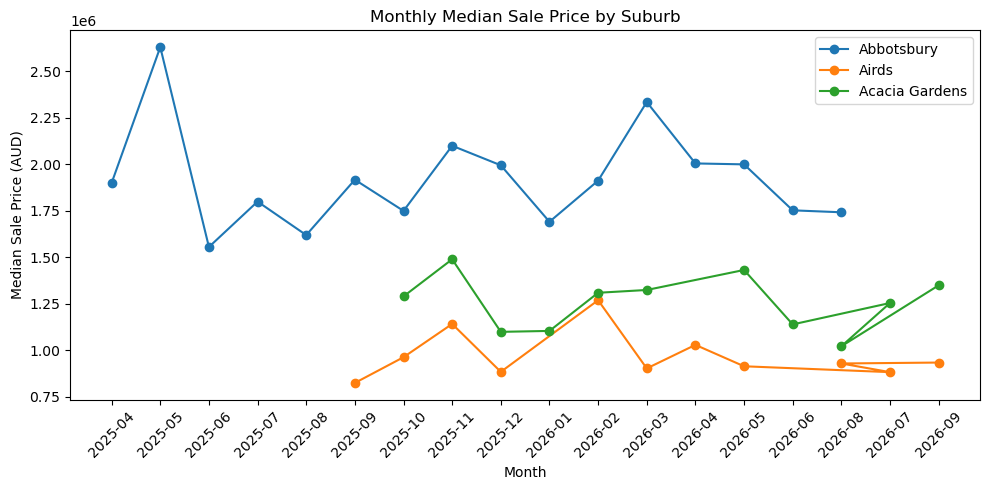

In [17]:
plt.figure(figsize=(10, 5))

for suburb in monthly_prices["Suburb"].unique():
    subset = monthly_prices[monthly_prices["Suburb"] == suburb]
    
    plt.plot(
        subset["Year_Month"],
        subset["Sale_Price_AUD"],
        marker="o",
        label=suburb
    )

plt.title("Monthly Median Sale Price by Suburb")
plt.xlabel("Month")
plt.ylabel("Median Sale Price (AUD)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
Q1 = df["Sale_Price_AUD"].quantile(0.25)
Q3 = df["Sale_Price_AUD"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[
    (df["Sale_Price_AUD"] < lower_bound) |
    (df["Sale_Price_AUD"] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

price_outliers[
    ["Suburb", "Address", "Sale_Price_AUD", "Bedrooms", "Bathrooms", "Car_Spaces", "Land_Size_m2"]
]

Lower bound: -62250.0
Upper bound: 2743750.0


,Suburb,Address,Sale_Price_AUD,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2


In [19]:
print("Highest bedroom counts:")
display(
    df.nlargest(5, "Bedrooms")[
        ["Suburb", "Address", "Bedrooms", "Sale_Price_AUD"]
    ]
)

print("\nHighest car-space counts:")
display(
    df.nlargest(5, "Car_Spaces")[
        ["Suburb", "Address", "Car_Spaces", "Sale_Price_AUD"]
    ]
)

print("\nLargest land sizes:")
display(
    df.nlargest(5, "Land_Size_m2")[
        ["Suburb", "Address", "Land_Size_m2", "Sale_Price_AUD"]
    ]
)

Highest bedroom counts:


,Suburb,Address,Bedrooms,Sale_Price_AUD
24,Abbotsbury,18 Martens Place,7,2120000
5,Abbotsbury,2 Hackett Road,6,2620000
21,Abbotsbury,4 Darling Street,6,1670000
34,Abbotsbury,13 Martens Place,6,1900000
79,Airds,26 Axford Avenue,6,1310000



Highest car-space counts:


,Suburb,Address,Car_Spaces,Sale_Price_AUD
21,Abbotsbury,4 Darling Street,13.0,1670000
48,Acacia Gardens,8 Osbert Place,5.0,1325000
60,Acacia Gardens,14 Rulana Street,4.0,1670000
75,Airds,19 Kelburn Place,4.0,860000
94,Airds,8 & 8A Nandewar Avenue,4.0,1275000



Largest land sizes:


,Suburb,Address,Land_Size_m2,Sale_Price_AUD
29,Abbotsbury,15 Begovich Crescent,1049.0,1800000
22,Abbotsbury,5 Whitley Place,840.3,1830000
10,Abbotsbury,9 Falmer Street,828.0,2420000
33,Abbotsbury,15 Lanceley Place,751.0,2630000
4,Abbotsbury,9 Comin Place,749.0,1753000


In [20]:
correlation = df[
    ["Sale_Price_AUD", "Bedrooms", "Bathrooms", "Car_Spaces", "Land_Size_m2"]
].corr()

print(correlation["Sale_Price_AUD"].sort_values(ascending=False))

Sale_Price_AUD    1.000000
Bathrooms         0.682839
Land_Size_m2      0.607925
Bedrooms          0.577211
Car_Spaces        0.253971
Name: Sale_Price_AUD, dtype: float64


In [21]:
df["Total_Rooms"] = df["Bedrooms"] + df["Bathrooms"]

df["Has_Parking"] = df["Car_Spaces"].apply(
    lambda x: 1 if pd.notnull(x) and x > 0 else 0
)

df["Sale_Year"] = df["Sale_Date"].dt.year
df["Sale_Month"] = df["Sale_Date"].dt.month

df[
    ["Bedrooms", "Bathrooms", "Total_Rooms",
     "Car_Spaces", "Has_Parking", "Sale_Year", "Sale_Month"]
].head()

,Bedrooms,Bathrooms,Total_Rooms,Car_Spaces,Has_Parking,Sale_Year,Sale_Month
0,4,3,7,3.0,1,2026,8
1,4,2,6,2.0,1,2026,8
2,4,2,6,3.0,1,2026,8
3,4,2,6,2.0,1,2026,8
4,4,3,7,2.0,1,2026,6


In [22]:
df = df.drop(columns=["Has_Parking"])

df["Days_Since_First_Sale"] = (
    df["Sale_Date"] - df["Sale_Date"].min()
).dt.days

df[
    ["Bedrooms", "Bathrooms", "Total_Rooms",
     "Sale_Year", "Sale_Month", "Days_Since_First_Sale"]
].head()

,Bedrooms,Bathrooms,Total_Rooms,Sale_Year,Sale_Month,Days_Since_First_Sale
0,4,3,7,2026,8,501
1,4,2,6,2026,8,499
2,4,2,6,2026,8,499
3,4,2,6,2026,8,486
4,4,3,7,2026,6,433


In [23]:
engineered_corr = df[
    [
        "Sale_Price_AUD",
        "Total_Rooms",
        "Sale_Year",
        "Sale_Month",
        "Days_Since_First_Sale"
    ]
].corr()

print(engineered_corr["Sale_Price_AUD"].sort_values(ascending=False))

Sale_Price_AUD           1.000000
Total_Rooms              0.668169
Sale_Month              -0.045767
Sale_Year               -0.183103
Days_Since_First_Sale   -0.276053
Name: Sale_Price_AUD, dtype: float64


In [24]:
from sklearn.model_selection import train_test_split

model_df = df[
    [
        "Suburb",
        "Property_Type",
        "Bedrooms",
        "Bathrooms",
        "Car_Spaces",
        "Land_Size_m2",
        "Total_Rooms",
        "Sale_Year",
        "Sale_Month",
        "Days_Since_First_Sale",
        "Sale_Price_AUD"
    ]
].copy()

model_df["Car_Spaces"] = model_df["Car_Spaces"].fillna(
    model_df["Car_Spaces"].median()
)

model_df["Land_Size_m2"] = model_df["Land_Size_m2"].fillna(
    model_df["Land_Size_m2"].median()
)

model_df = pd.get_dummies(
    model_df,
    columns=["Suburb", "Property_Type"],
    drop_first=True
)

model_df.head()

,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Total_Rooms,Sale_Year,Sale_Month,Days_Since_First_Sale,Sale_Price_AUD,Suburb_Acacia Gardens,Suburb_Airds,Property_Type_House,Property_Type_Townhouse
0,4,3,3.0,685.0,7,2026,8,501,1690000,False,False,True,False
1,4,2,2.0,745.6,6,2026,8,499,1795000,False,False,True,False
2,4,2,3.0,608.0,6,2026,8,499,1601000,False,False,True,False
3,4,2,2.0,531.0,6,2026,8,486,1800000,False,False,True,False
4,4,3,2.0,749.0,7,2026,6,433,1753000,False,False,True,False


In [25]:
print("Missing values remaining:")
print(model_df.isnull().sum().sum())

print("\nModel dataset shape:")
print(model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

Missing values remaining:
0

Model dataset shape:
(105, 13)

Columns:
['Bedrooms', 'Bathrooms', 'Car_Spaces', 'Land_Size_m2', 'Total_Rooms', 'Sale_Year', 'Sale_Month', 'Days_Since_First_Sale', 'Sale_Price_AUD', 'Suburb_Acacia Gardens', 'Suburb_Airds', 'Property_Type_House', 'Property_Type_Townhouse']


In [26]:
X = model_df.drop(columns=["Sale_Price_AUD"])
y = model_df["Sale_Price_AUD"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (84, 12)
Test set: (21, 12)


In [27]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(kf)

KFold(n_splits=5, random_state=42, shuffle=True)


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_model = LinearRegression()

# 5-fold cross-validation on the training set
cv_mae = -cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

cv_rmse = np.sqrt(
    -cross_val_score(
        linear_model,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
)

cv_r2 = cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)

print("Linear Regression Cross-Validation Results")
print("Mean CV MAE:", cv_mae.mean())
print("Mean CV RMSE:", cv_rmse.mean())
print("Mean CV R²:", cv_r2.mean())

Linear Regression Cross-Validation Results
Mean CV MAE: 135589.9104532782
Mean CV RMSE: 181921.79130437164
Mean CV R²: 0.810429792225144


In [29]:
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Test Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression Test Results
MAE: 132791.08938102494
RMSE: 195805.9865590727
R²: 0.8484284242560416


In [30]:
linear_train_pred = linear_model.predict(X_train)

linear_train_mae = mean_absolute_error(y_train, linear_train_pred)
linear_train_rmse = np.sqrt(mean_squared_error(y_train, linear_train_pred))
linear_train_r2 = r2_score(y_train, linear_train_pred)

print("Linear Regression Training Results")
print("MAE:", linear_train_mae)
print("RMSE:", linear_train_rmse)
print("R²:", linear_train_r2)

print("\nLinear Regression Test Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression Training Results
MAE: 109864.10344155629
RMSE: 140773.30281789336
R²: 0.9035890948950891

Linear Regression Test Results
MAE: 132791.08938102494
RMSE: 195805.9865590727
R²: 0.8484284242560416


In [31]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

# 5-fold cross-validation
tree_cv_mae = -cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

tree_cv_rmse = np.sqrt(
    -cross_val_score(
        tree_model,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
)

tree_cv_r2 = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)

print("Decision Tree Cross-Validation Results")
print("Mean CV MAE:", tree_cv_mae.mean())
print("Mean CV RMSE:", tree_cv_rmse.mean())
print("Mean CV R²:", tree_cv_r2.mean())

Decision Tree Cross-Validation Results
Mean CV MAE: 214100.3676470588
Mean CV RMSE: 294981.52781810024
Mean CV R²: 0.503896136393382


In [32]:
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Test Results")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R²:", tree_r2)

Decision Tree Test Results
MAE: 335476.1904761905
RMSE: 457641.3390834522
R²: 0.17202670510248264


In [33]:
tree_train_pred = tree_model.predict(X_train)

tree_train_mae = mean_absolute_error(y_train, tree_train_pred)
tree_train_rmse = np.sqrt(mean_squared_error(y_train, tree_train_pred))
tree_train_r2 = r2_score(y_train, tree_train_pred)

print("Decision Tree Training Results")
print("MAE:", tree_train_mae)
print("RMSE:", tree_train_rmse)
print("R²:", tree_train_r2)

print("\nDecision Tree Test Results")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R²:", tree_r2)

Decision Tree Training Results
MAE: 0.0
RMSE: 0.0
R²: 1.0

Decision Tree Test Results
MAE: 335476.1904761905
RMSE: 457641.3390834522
R²: 0.17202670510248264


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# 5-fold cross-validation
rf_cv_mae = -cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

rf_cv_rmse = np.sqrt(
    -cross_val_score(
        rf_model,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
)

rf_cv_r2 = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)

print("Random Forest Cross-Validation Results")
print("Mean CV MAE:", rf_cv_mae.mean())
print("Mean CV RMSE:", rf_cv_rmse.mean())
print("Mean CV R²:", rf_cv_r2.mean())

Random Forest Cross-Validation Results
Mean CV MAE: 162914.09375
Mean CV RMSE: 219953.99658048028
Mean CV R²: 0.7427666753915299


In [35]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Test Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Test Results
MAE: 187626.30952380953
RMSE: 263567.22592169826
R²: 0.7253695773666431


In [36]:
rf_train_pred = rf_model.predict(X_train)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_r2 = r2_score(y_train, rf_train_pred)

print("Random Forest Training Results")
print("MAE:", rf_train_mae)
print("RMSE:", rf_train_rmse)
print("R²:", rf_train_r2)

print("\nRandom Forest Test Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Training Results
MAE: 56483.69047619047
RMSE: 77267.01023037243
R²: 0.9709548398307767

Random Forest Test Results
MAE: 187626.30952380953
RMSE: 263567.22592169826
R²: 0.7253695773666431


In [37]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "CV_R2": [
        cv_r2.mean(),
        tree_cv_r2.mean(),
        rf_cv_r2.mean()
    ],
    "Test_MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "Test_RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "Test_R2": [
        linear_r2,
        tree_r2,
        rf_r2
    ],
    "Train_R2": [
        linear_train_r2,
        tree_train_r2,
        rf_train_r2
    ]
})

results.round(3)

,Model,CV_R2,Test_MAE,Test_RMSE,Test_R2,Train_R2
0,Linear Regression,0.810,132791.089,195805.987,0.848,0.904
1,Decision Tree,0.504,335476.190,457641.339,0.172,1.000
2,Random Forest,0.743,187626.310,263567.226,0.725,0.971


In [38]:
tree_depth_results = []

for depth in [2, 3, 4, 5, 6, 8, 10, None]:
    
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    
    tree_depth_results.append({
        "Max_Depth": str(depth),
        "Train_R2": train_r2,
        "Test_R2": test_r2
    })

depth_results = pd.DataFrame(tree_depth_results)

depth_results.round(3)

,Max_Depth,Train_R2,Test_R2
0,2,0.693,0.483
1,3,0.842,0.447
2,4,0.916,0.249
3,5,0.953,0.263
4,6,0.971,0.223
5,8,0.984,0.175
6,10,0.994,0.152
7,None,1.000,0.172


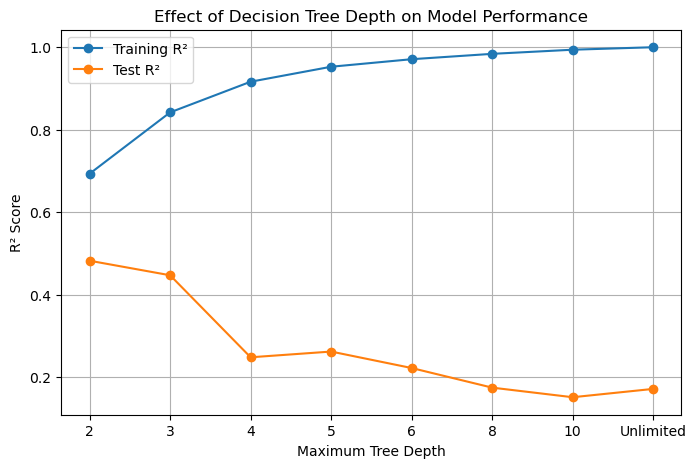

In [39]:
plot_depth = depth_results.copy()

plot_depth["Max_Depth"] = plot_depth["Max_Depth"].replace(
    "None", "Unlimited"
)

plt.figure(figsize=(8, 5))

plt.plot(
    plot_depth["Max_Depth"],
    plot_depth["Train_R2"],
    marker="o",
    label="Training R²"
)

plt.plot(
    plot_depth["Max_Depth"],
    plot_depth["Test_R2"],
    marker="o",
    label="Test R²"
)

plt.title("Effect of Decision Tree Depth on Model Performance")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)

plt.show()

In [40]:
from sklearn.model_selection import cross_val_predict

linear_oof_pred = cross_val_predict(
    LinearRegression(),
    X,
    y,
    cv=kf
)

error_analysis = df[
    [
        "Address",
        "Suburb",
        "Property_Type",
        "Sale_Price_AUD",
        "Bedrooms",
        "Bathrooms",
        "Car_Spaces",
        "Land_Size_m2"
    ]
].copy()

error_analysis["Predicted_Price"] = linear_oof_pred

error_analysis["Prediction_Error"] = (
    error_analysis["Sale_Price_AUD"] -
    error_analysis["Predicted_Price"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Prediction_Error"].abs()
)

top_5_errors = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(5)

top_5_errors.round(0)

,Address,Suburb,Property_Type,Sale_Price_AUD,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Predicted_Price,Prediction_Error,Absolute_Error
21,4 Darling Street,Abbotsbury,House,1670000,6,3,13.0,601.0,2482845.0,-812845.0,812845.0
33,15 Lanceley Place,Abbotsbury,House,2630000,5,3,3.0,751.0,2050405.0,579595.0,579595.0
34,13 Martens Place,Abbotsbury,House,1900000,6,4,2.0,584.0,2342501.0,-442501.0,442501.0
15,23 Ilford Place,Abbotsbury,House,2380000,4,3,2.0,700.0,1975038.0,404962.0,404962.0
28,2 Thorpe Place,Abbotsbury,House,1620000,5,3,2.0,451.0,2000226.0,-380226.0,380226.0


In [41]:
top_5_indices = top_5_errors.index

df.loc[
    top_5_indices,
    [
        "Address",
        "Suburb",
        "Sale_Date",
        "Property_Type",
        "Bedrooms",
        "Bathrooms",
        "Car_Spaces",
        "Land_Size_m2",
        "Sale_Price_AUD",
        "Notes",
        "Source_URL"
    ]
]

,Address,Suburb,Sale_Date,Property_Type,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2,Sale_Price_AUD,Notes,Source_URL
21,4 Darling Street,Abbotsbury,2025-10-02,House,6,3,13.0,601.0,1670000,Listing states 13 off-street car spaces.,https://www.realestate.com.au/sold/property-ho...
33,15 Lanceley Place,Abbotsbury,2025-05-31,House,5,3,3.0,751.0,2630000,NaN,https://www.realestate.com.au/sold/property-ho...
34,13 Martens Place,Abbotsbury,2025-04-10,House,6,4,2.0,583.9,1900000,NaN,https://www.realestate.com.au/sold/property-ho...
15,23 Ilford Place,Abbotsbury,2025-12-18,House,4,3,2.0,700.0,2380000,NaN,https://www.realestate.com.au/sold/property-ho...
28,2 Thorpe Place,Abbotsbury,2025-08-25,House,5,3,2.0,451.2,1620000,NaN,https://www.realestate.com.au/sold/property-ho...


In [42]:
top_5_details = error_analysis.loc[
    top_5_errors.index,
    [
        "Address",
        "Sale_Price_AUD",
        "Predicted_Price",
        "Prediction_Error",
        "Absolute_Error",
        "Bedrooms",
        "Bathrooms",
        "Car_Spaces",
        "Land_Size_m2"
    ]
]

top_5_details.round(0)

,Address,Sale_Price_AUD,Predicted_Price,Prediction_Error,Absolute_Error,Bedrooms,Bathrooms,Car_Spaces,Land_Size_m2
21,4 Darling Street,1670000,2482845.0,-812845.0,812845.0,6,3,13.0,601.0
33,15 Lanceley Place,2630000,2050405.0,579595.0,579595.0,5,3,3.0,751.0
34,13 Martens Place,1900000,2342501.0,-442501.0,442501.0,6,4,2.0,584.0
15,23 Ilford Place,2380000,1975038.0,404962.0,404962.0,4,3,2.0,700.0
28,2 Thorpe Place,1620000,2000226.0,-380226.0,380226.0,5,3,2.0,451.0


In [43]:
df.loc[
    top_5_errors.index,
    ["Address", "Notes"]
]

,Address,Notes
21,4 Darling Street,Listing states 13 off-street car spaces.
33,15 Lanceley Place,NaN
34,13 Martens Place,NaN
15,23 Ilford Place,NaN
28,2 Thorpe Place,NaN


In [44]:
df.loc[
    top_5_errors.index,
    ["Address", "Source_URL"]
]

,Address,Source_URL
21,4 Darling Street,https://www.realestate.com.au/sold/property-ho...
33,15 Lanceley Place,https://www.realestate.com.au/sold/property-ho...
34,13 Martens Place,https://www.realestate.com.au/sold/property-ho...
15,23 Ilford Place,https://www.realestate.com.au/sold/property-ho...
28,2 Thorpe Place,https://www.realestate.com.au/sold/property-ho...


In [45]:
pd.set_option("display.max_colwidth", None)

print(
    df.loc[
        top_5_errors.index,
        ["Address", "Source_URL"]
    ].to_string(index=False)
)

          Address                                                                 Source_URL
 4 Darling Street https://www.realestate.com.au/sold/property-house-nsw-abbotsbury-148030928
15 Lanceley Place https://www.realestate.com.au/sold/property-house-nsw-abbotsbury-147932916
 13 Martens Place https://www.realestate.com.au/sold/property-house-nsw-abbotsbury-147601452
  23 Ilford Place https://www.realestate.com.au/sold/property-house-nsw-abbotsbury-149489384
   2 Thorpe Place https://www.realestate.com.au/sold/property-house-nsw-abbotsbury-148512540


In [46]:
import joblib

joblib.dump(linear_model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [47]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [48]:
first_sale_date = df["Sale_Date"].min()

joblib.dump(first_sale_date, "first_sale_date.pkl")

print("First sale date:", first_sale_date)

First sale date: 2025-04-10 00:00:00


In [49]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load trained model and supporting files
model = joblib.load("linear_regression_model.pkl")
model_columns = joblib.load("model_columns.pkl")
first_sale_date = joblib.load("first_sale_date.pkl")

st.title("Sydney Housing Price Prediction")
st.write(
    "Enter the property details below to estimate the expected sale price."
)

# User inputs
suburb = st.selectbox(
    "Suburb",
    ["Abbotsbury", "Acacia Gardens", "Airds"]
)

property_type = st.selectbox(
    "Property Type",
    ["House", "Townhouse", "Duplex"]
)

bedrooms = st.number_input(
    "Bedrooms",
    min_value=1,
    max_value=10,
    value=4
)

bathrooms = st.number_input(
    "Bathrooms",
    min_value=1,
    max_value=10,
    value=2
)

car_spaces = st.number_input(
    "Car Spaces",
    min_value=0,
    max_value=20,
    value=2
)

land_size = st.number_input(
    "Land Size (m²)",
    min_value=0.0,
    value=500.0
)

sale_date = st.date_input(
    "Expected Sale Date"
)

if st.button("Predict Sale Price"):

    sale_date = pd.Timestamp(sale_date)

    total_rooms = bedrooms + bathrooms
    sale_year = sale_date.year
    sale_month = sale_date.month

    days_since_first_sale = (
        sale_date - first_sale_date
    ).days

    # Start with all model features set to zero
    input_data = {
        column: 0
        for column in model_columns
    }

    # Numeric features
    input_data["Bedrooms"] = bedrooms
    input_data["Bathrooms"] = bathrooms
    input_data["Car_Spaces"] = car_spaces
    input_data["Land_Size_m2"] = land_size
    input_data["Total_Rooms"] = total_rooms
    input_data["Sale_Year"] = sale_year
    input_data["Sale_Month"] = sale_month
    input_data["Days_Since_First_Sale"] = days_since_first_sale

    # Suburb encoding
    if suburb == "Acacia Gardens":
        input_data["Suburb_Acacia Gardens"] = 1

    elif suburb == "Airds":
        input_data["Suburb_Airds"] = 1

    # Abbotsbury is the reference category

    # Property type encoding
    if property_type == "House":
        input_data["Property_Type_House"] = 1

    elif property_type == "Townhouse":
        input_data["Property_Type_Townhouse"] = 1

    # Duplex is the reference category

    input_df = pd.DataFrame(
        [input_data],
        columns=model_columns
    )

    prediction = model.predict(input_df)[0]

    st.success(
        f"Estimated Sale Price: ${prediction:,.0f}"
    )

    st.caption(
        "This prediction is an estimate based on the available dataset and should not be treated as a professional property valuation."
    )

Overwriting app.py


In [50]:
!pip install gradio

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   -- ------------------------------------- 1.6/31.4 MB 7.8 MB/s eta 0:00:04
   ---- ----------------------------------- 3.1/31.4 MB 7.5 MB/s eta 0:00:04
   ------ --------------------------------- 4.7/31.4 MB 7.2 MB/s eta 0:00:04
   ------- -------------------------------- 6.0/31.4 MB 6.9 MB/s eta 0:00:04
   -------- ------------------------------- 6.8/31.4 MB 6.4 MB/s eta 0:00:04
   --------- ------------------------------ 7.6/31.4 MB 5.8 MB/s eta 0:00:05
   ---------- ----------------------------- 8.1/31.4 MB 5.5 MB/s eta 0:00:05
   ----------- ---------------------------- 8.7/31.4 MB 5.1 MB/s eta 0:00:05
   ----------- ---------------------------- 8.9/31.4 MB 4.7 MB/s eta 0:00:05
   ------------ --------------------------- 9.4/31.4 MB 4.3 MB/s eta 0:00:06
   ------------ --------------------------- 9.7/31.4 MB 4.2 MB/s eta 0:00:06
   ------------ ----


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import gradio as gr

In [52]:
import joblib

model = joblib.load("linear_regression_model.pkl")
model_columns = joblib.load("model_columns.pkl")
first_sale_date = joblib.load("first_sale_date.pkl")

print(model_columns)

['Bedrooms', 'Bathrooms', 'Car_Spaces', 'Land_Size_m2', 'Total_Rooms', 'Sale_Year', 'Sale_Month', 'Days_Since_First_Sale', 'Suburb_Acacia Gardens', 'Suburb_Airds', 'Property_Type_House', 'Property_Type_Townhouse']


In [53]:
def predict_price(
    suburb,
    property_type,
    bedrooms,
    bathrooms,
    car_spaces,
    land_size,
    sale_date
):
    sale_date = pd.Timestamp(sale_date)

    input_data = {column: 0 for column in model_columns}

    input_data["Bedrooms"] = bedrooms
    input_data["Bathrooms"] = bathrooms
    input_data["Car_Spaces"] = car_spaces
    input_data["Land_Size_m2"] = land_size
    input_data["Total_Rooms"] = bedrooms + bathrooms
    input_data["Sale_Year"] = sale_date.year
    input_data["Sale_Month"] = sale_date.month
    input_data["Days_Since_First_Sale"] = (
        sale_date - first_sale_date
    ).days

    if suburb == "Acacia Gardens":
        input_data["Suburb_Acacia Gardens"] = 1
    elif suburb == "Airds":
        input_data["Suburb_Airds"] = 1

    if property_type == "House":
        input_data["Property_Type_House"] = 1
    elif property_type == "Townhouse":
        input_data["Property_Type_Townhouse"] = 1

    input_df = pd.DataFrame(
        [input_data],
        columns=model_columns
    )

    prediction = model.predict(input_df)[0]

    return f"${prediction:,.0f}"

In [54]:
import gradio as gr
import pandas as pd

def predict_price(
    suburb,
    property_type,
    bedrooms,
    bathrooms,
    car_spaces,
    land_size,
    sale_date
):
    sale_date = pd.Timestamp(sale_date)

    total_rooms = bedrooms + bathrooms
    sale_year = sale_date.year
    sale_month = sale_date.month
    days_since_first_sale = (sale_date - first_sale_date).days

    input_data = {column: 0 for column in model_columns}

    input_data["Bedrooms"] = bedrooms
    input_data["Bathrooms"] = bathrooms
    input_data["Car_Spaces"] = car_spaces
    input_data["Land_Size_m2"] = land_size
    input_data["Total_Rooms"] = total_rooms
    input_data["Sale_Year"] = sale_year
    input_data["Sale_Month"] = sale_month
    input_data["Days_Since_First_Sale"] = days_since_first_sale

    if suburb == "Acacia Gardens":
        input_data["Suburb_Acacia Gardens"] = 1
    elif suburb == "Airds":
        input_data["Suburb_Airds"] = 1

    if property_type == "House":
        input_data["Property_Type_House"] = 1
    elif property_type == "Townhouse":
        input_data["Property_Type_Townhouse"] = 1

    input_df = pd.DataFrame([input_data], columns=model_columns)

    prediction = linear_model.predict(input_df)[0]

    return f"${prediction:,.0f}"


app = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Dropdown(
            ["Abbotsbury", "Acacia Gardens", "Airds"],
            label="Suburb"
        ),
        gr.Dropdown(
            ["House", "Townhouse", "Duplex"],
            label="Property Type"
        ),
        gr.Number(label="Bedrooms", value=4),
        gr.Number(label="Bathrooms", value=2),
        gr.Number(label="Car Spaces", value=2),
        gr.Number(label="Land Size (m²)", value=500),
        gr.Textbox(
            label="Expected Sale Date",
            value="2026-09-18"
        )
    ],
    outputs=gr.Textbox(label="Estimated Sale Price"),
    title="Sydney Housing Price Prediction",
    description="Enter property details to estimate the expected sale price."
)

app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
